"""
Phase 4: Neural Operators — DeepONet and Fourier Neural Operator (FNO)
=======================================================================
pip install torch numpy matplotlib

The key idea: instead of learning a single function u(x),
we learn an *operator* G: f ↦ u that maps entire functions to functions.
This lets one trained model handle any input condition — not just the ones it saw.

Example 1 — DeepONet: Learn the antiderivative operator G(f)(x) = ∫₀ˣ f(t) dt
Example 2 — FNO-1D:   Learn the solution operator for the 1D Poisson equation
                        G: f ↦ u where –u'' = f on [0,1] with u(0)=u(1)=0
"""

In [1]:
import torch
import torch.nn as nn
import torch.fft as fft
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}\n")


Device: cpu



In [2]:
# ═══════════════════════════════════════════════════════════════
# EXAMPLE 1: DeepONet — antiderivative operator
#
# Architecture:
#   Branch net:  encodes f at fixed sensor locations → vector b ∈ ℝᵖ
#   Trunk net:   encodes query location x            → vector t ∈ ℝᵖ
#   Output:      G(f)(x) ≈ b · t  (inner product)
#
# Why it works: branch learns "what function is this?",
# trunk learns "basis functions over the output space",
# the dot product mixes them to evaluate at any x.
# ═══════════════════════════════════════════════════════════════

print("=" * 60)
print("EXAMPLE 1: DeepONet — antiderivative operator")
print("=" * 60)

N_SENSORS = 50     # where branch net reads the input function
P         = 64     # inner dimension of branch/trunk


def make_dataset(n_funcs: int, n_queries: int, n_sensors: int = N_SENSORS):
    """
    Random input functions: f(x) = Σ aₖ·sin(kπx) + bₖ·cos(kπx), k=1..5
    Antiderivative computed analytically: ∫₀ˣ f = Σ –aₖ/kπ·cos(kπx) + bₖ/kπ·sin(kπx) + const
    """
    s = torch.linspace(0, 1, n_sensors)  # sensor locations

    branch_in = torch.zeros(n_funcs * n_queries, n_sensors)
    x_query   = torch.zeros(n_funcs * n_queries, 1)
    y_target  = torch.zeros(n_funcs * n_queries, 1)

    k_vals = torch.arange(1, 6).float()
    idx = 0
    for _ in range(n_funcs):
        a = torch.randn(5)
        b = torch.randn(5)

        def f(x):
            return (a * torch.sin(k_vals * torch.pi * x.unsqueeze(-1))
                  + b * torch.cos(k_vals * torch.pi * x.unsqueeze(-1))).sum(-1)

        def F(x):   # antiderivative s.t. F(0) = 0
            return ((-a / (k_vals * torch.pi)) * torch.cos(k_vals * torch.pi * x.unsqueeze(-1))
                   + (b / (k_vals * torch.pi)) * torch.sin(k_vals * torch.pi * x.unsqueeze(-1))
                   + (a / (k_vals * torch.pi)).sum()  # constant term to enforce F(0)=0
            ).sum(-1) - ((-a / (k_vals * torch.pi)) * 1 + 0).sum()  # subtract F(0)

        # Recalculate correctly: F(x) - F(0)
        def G(x):
            term = (-a / (k_vals * torch.pi)) * torch.cos(k_vals * torch.pi * x.unsqueeze(-1)) \
                 + ( b / (k_vals * torch.pi)) * torch.sin(k_vals * torch.pi * x.unsqueeze(-1))
            return term.sum(-1)

        G0 = G(torch.tensor([0.0]))[0]   # subtract so G(0)=0
        f_sens = f(s)                     # shape (n_sensors,)

        xs = torch.rand(n_queries)
        ys = G(xs) - G0

        for i in range(n_queries):
            branch_in[idx] = f_sens
            x_query[idx, 0] = xs[i]
            y_target[idx, 0] = ys[i]
            idx += 1

    return branch_in, x_query, y_target


class BranchNet(nn.Module):
    def __init__(self, n_sensors=N_SENSORS, hidden=128, p=P):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_sensors, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden),    nn.Tanh(),
            nn.Linear(hidden, p)
        )
    def forward(self, f):        # f: (batch, n_sensors)
        return self.net(f)       # → (batch, P)


class TrunkNet(nn.Module):
    def __init__(self, hidden=128, p=P):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, p),
            nn.Tanh()              # trunk final activation is non-linear
        )
    def forward(self, x):        # x: (batch, 1)
        return self.net(x)       # → (batch, P)


class DeepONet(nn.Module):
    def __init__(self):
        super().__init__()
        self.branch = BranchNet()
        self.trunk  = TrunkNet()
        self.bias   = nn.Parameter(torch.zeros(1))

    def forward(self, f_sensors, x_query):
        b = self.branch(f_sensors)                     # (batch, P)
        t = self.trunk(x_query)                        # (batch, P)
        return (b * t).sum(dim=-1, keepdim=True) + self.bias


# ── Generate data ──────────────────────────────────────────────
print("Generating DeepONet training data …")
B_tr, X_tr, Y_tr = make_dataset(n_funcs=2000, n_queries=50)
B_va, X_va, Y_va = make_dataset(n_funcs=200,  n_queries=50)
B_tr, X_tr, Y_tr = B_tr.to(device), X_tr.to(device), Y_tr.to(device)
B_va, X_va, Y_va = B_va.to(device), X_va.to(device), Y_va.to(device)
print(f"  Train: {B_tr.shape[0]} samples | Val: {B_va.shape[0]} samples\n")

deeponet = DeepONet().to(device)
opt = torch.optim.Adam(deeponet.parameters(), lr=1e-3)
sched = torch.optim.lr_scheduler.StepLR(opt, step_size=5000, gamma=0.5)

BATCH = 4096
for step in range(20_001):
    idx = torch.randperm(B_tr.shape[0], device=device)[:BATCH]
    pred = deeponet(B_tr[idx], X_tr[idx])
    loss = nn.functional.mse_loss(pred, Y_tr[idx])
    opt.zero_grad(); loss.backward(); opt.step(); sched.step()

    if step % 5000 == 0:
        with torch.no_grad():
            val_loss = nn.functional.mse_loss(deeponet(B_va, X_va), Y_va)
        print(f"  step {step:6d} | train MSE: {loss.item():.2e} | val MSE: {val_loss.item():.2e}")

# Relative L2 on validation
with torch.no_grad():
    val_pred = deeponet(B_va, X_va)
rel_l2 = ((val_pred - Y_va).pow(2).mean().sqrt()
          / (Y_va.pow(2).mean().sqrt() + 1e-8)).item()
print(f"\n  Relative L2 error: {rel_l2:.4f}  (target < 0.02)\n")

EXAMPLE 1: DeepONet — antiderivative operator
Generating DeepONet training data …
  Train: 100000 samples | Val: 10000 samples

  step      0 | train MSE: 3.08e-01 | val MSE: 1.71e-01
  step   5000 | train MSE: 4.41e-04 | val MSE: 1.97e-04
  step  10000 | train MSE: 7.65e-05 | val MSE: 4.07e-05
  step  15000 | train MSE: 2.01e-05 | val MSE: 2.33e-05
  step  20000 | train MSE: 1.31e-05 | val MSE: 1.80e-05

  Relative L2 error: 0.0076  (target < 0.02)



EXAMPLE 2: Fourier Neural Operator (FNO-1D)
Generating Poisson dataset …
  Train: torch.Size([4000, 128])  |  Val: torch.Size([400, 128])

  epoch   0 | step    63 | val rel-L2: 0.6592
  epoch  10 | step   693 | val rel-L2: 0.1212
  epoch  20 | step  1323 | val rel-L2: 0.1156
  epoch  30 | step  1953 | val rel-L2: 0.0800
  epoch  40 | step  2583 | val rel-L2: 0.0796
  epoch  50 | step  3213 | val rel-L2: 0.0845
  epoch  60 | step  3843 | val rel-L2: 0.0611
  epoch  70 | step  4473 | val rel-L2: 0.0574
  epoch  79 | step  5040 | val rel-L2: 0.0577

  Final val relative L2: 0.0577  (target < 0.02)

Plot saved → phase4_fno_poisson.png


AttributeError: module 'numpy' has no attribute 'trapz'

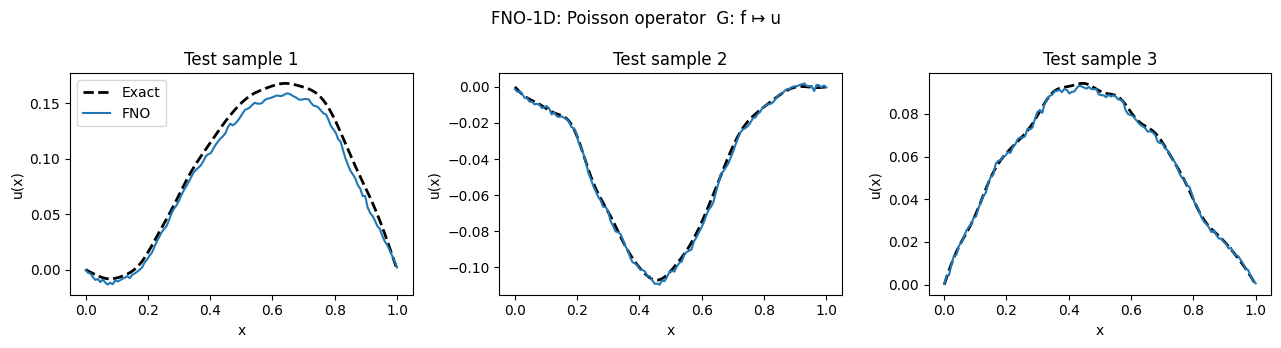

In [3]:
# ═══════════════════════════════════════════════════════════════
# EXAMPLE 2: Fourier Neural Operator (FNO-1D)
#
# Problem: Learn G: f ↦ u  where –u'' = f, u(0)=u(1)=0
# FNO lifts f to a channel space, applies spectral convolutions
# (multiplication in Fourier domain), and projects back.
#
# Key idea: convolution in physical space = pointwise multiplication
# in Fourier space. FNO learns those multiplications directly,
# giving global receptive field at every layer.
# ═══════════════════════════════════════════════════════════════

print("=" * 60)
print("EXAMPLE 2: Fourier Neural Operator (FNO-1D)")
print("=" * 60)

N_GRID  = 128    # discretisation points
N_MODES = 16     # Fourier modes to keep per layer
WIDTH   = 32     # channel width


def poisson_dataset(n_funcs: int, n_grid: int = N_GRID):
    """
    Random f = Σ aₖ sin(kπx), solve –u'' = f analytically.
    Exact: u(x) = Σ aₖ/(kπ)² sin(kπx)
    Returns f and u as (n_funcs, n_grid) tensors.
    """
    x = torch.linspace(0, 1, n_grid)
    k = torch.arange(1, 21).float()              # 20 modes

    a = torch.randn(n_funcs, 20)                 # random amplitudes
    # f shape: (n_funcs, n_grid)
    f = (a.unsqueeze(2) * torch.sin(k.unsqueeze(0).unsqueeze(2)
         * torch.pi * x.unsqueeze(0).unsqueeze(0))).sum(1)
    u = (a.unsqueeze(2) / (k.unsqueeze(0).unsqueeze(2) * torch.pi).pow(2)
         * torch.sin(k.unsqueeze(0).unsqueeze(2)
         * torch.pi * x.unsqueeze(0).unsqueeze(0))).sum(1)
    return f, u


class SpectralConv1d(nn.Module):
    """
    FNO spectral layer: truncated Fourier convolution.
    Learns R ∈ ℂ^(in_channels × out_channels × n_modes).
    """
    def __init__(self, in_ch, out_ch, n_modes):
        super().__init__()
        self.in_ch   = in_ch
        self.out_ch  = out_ch
        self.n_modes = n_modes
        scale = 1 / (in_ch * out_ch)
        self.weights = nn.Parameter(
            scale * torch.randn(in_ch, out_ch, n_modes, 2))  # last dim = real/imag

    def forward(self, x):
        # x: (batch, in_ch, n_grid)
        B, _, N = x.shape
        x_ft = fft.rfft(x, dim=-1)                     # (B, in_ch, N//2+1)

        # Complex weight from real representation
        W = torch.view_as_complex(self.weights)         # (in_ch, out_ch, n_modes)

        out_ft = torch.zeros(B, self.out_ch, N // 2 + 1,
                             dtype=torch.cfloat, device=x.device)
        # Einsum: mix channels in Fourier domain (only first n_modes)
        out_ft[:, :, :self.n_modes] = torch.einsum(
            "bim,iom->bom", x_ft[:, :, :self.n_modes], W)

        return fft.irfft(out_ft, n=N, dim=-1)           # back to physical space


class FNO1d(nn.Module):
    """
    Four FNO layers, each combining spectral conv + pointwise linear.
    Input:  (batch, 1, n_grid) — the forcing function f
    Output: (batch, 1, n_grid) — the solution u
    """
    def __init__(self, width=WIDTH, n_modes=N_MODES, n_layers=4):
        super().__init__()
        self.lift = nn.Conv1d(1, width, 1)          # lift: 1 ch → width ch

        self.spectral_layers = nn.ModuleList(
            [SpectralConv1d(width, width, n_modes) for _ in range(n_layers)])
        self.local_layers = nn.ModuleList(
            [nn.Conv1d(width, width, 1) for _ in range(n_layers)])

        self.project = nn.Sequential(
            nn.Conv1d(width, 32, 1), nn.GELU(),
            nn.Conv1d(32, 1, 1)                     # project: width → 1 ch
        )
        self.act = nn.GELU()

    def forward(self, x):
        # x: (batch, n_grid)
        x = x.unsqueeze(1)                          # → (batch, 1, n_grid)
        x = self.lift(x)                            # → (batch, width, n_grid)

        for spec, local in zip(self.spectral_layers, self.local_layers):
            x = self.act(spec(x) + local(x))        # residual-style combination

        return self.project(x).squeeze(1)           # → (batch, n_grid)


# ── Data ───────────────────────────────────────────────────────
print("Generating Poisson dataset …")
f_train, u_train = poisson_dataset(4000)
f_val,   u_val   = poisson_dataset(400)
f_train, u_train = f_train.to(device), u_train.to(device)
f_val,   u_val   = f_val.to(device),   u_val.to(device)
print(f"  Train: {f_train.shape}  |  Val: {f_val.shape}\n")

fno = FNO1d().to(device)
opt_fno = torch.optim.Adam(fno.parameters(), lr=1e-3)
sched_fno = torch.optim.lr_scheduler.CosineAnnealingLR(opt_fno, T_max=10_000)

BATCH_FNO = 64
ds = torch.utils.data.TensorDataset(f_train, u_train)
loader = torch.utils.data.DataLoader(ds, batch_size=BATCH_FNO, shuffle=True)

step = 0
for epoch in range(80):
    for f_b, u_b in loader:
        u_pred = fno(f_b)
        loss = nn.functional.mse_loss(u_pred, u_b)
        opt_fno.zero_grad(); loss.backward(); opt_fno.step(); sched_fno.step()
        step += 1

    if epoch % 10 == 0 or epoch == 79:
        with torch.no_grad():
            val_pred = fno(f_val)
            # Relative L2 (standard metric in neural operator papers)
            rel = ((val_pred - u_val).norm(dim=-1)
                   / (u_val.norm(dim=-1) + 1e-8)).mean().item()
        print(f"  epoch {epoch:3d} | step {step:5d} | val rel-L2: {rel:.4f}")

print(f"\n  Final val relative L2: {rel:.4f}  (target < 0.02)\n")


# ── Visualise FNO predictions ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
x_grid = torch.linspace(0, 1, N_GRID).numpy()

with torch.no_grad():
    preds = fno(f_val[:3]).cpu()

for i, ax in enumerate(axes):
    ax.plot(x_grid, u_val[i].cpu(), "k--", lw=2,   label="Exact")
    ax.plot(x_grid, preds[i],       "C0",  lw=1.5, label="FNO")
    ax.set_title(f"Test sample {i+1}")
    ax.set_xlabel("x"); ax.set_ylabel("u(x)")
    if i == 0: ax.legend()

fig.suptitle("FNO-1D: Poisson operator  G: f ↦ u", fontsize=12)
fig.tight_layout()
fig.savefig("phase4_fno_poisson.png", dpi=130)
print("Plot saved → phase4_fno_poisson.png")


# ── DeepONet plot ───────────────────────────────────────────────
# Show a single example: true vs predicted antiderivative curve
x_dense = torch.linspace(0, 1, 200).unsqueeze(1).to(device)
f_demo  = B_va[:1].expand(200, -1)

with torch.no_grad():
    y_demo = deeponet(f_demo, x_dense).cpu()

# Compute true antiderivative via trapezoidal rule for comparison
f_vals = torch.tensor(np.array(
    [float(B_va[0, int(s * (N_SENSORS-1))].cpu()) for s in
     np.linspace(0, 1, 200)]))

x_np = np.linspace(0, 1, 200)
y_true = np.array([np.trapz(f_vals[:i+1].numpy(), x_np[:i+1]) for i in range(200)])

fig2, ax2 = plt.subplots(figsize=(6, 3))
ax2.plot(x_np, y_true, "k--", lw=2, label="True ∫f")
ax2.plot(x_np, y_demo.squeeze().numpy(), "C1", lw=1.5, label="DeepONet")
ax2.set_title("DeepONet: antiderivative operator")
ax2.set_xlabel("x"); ax2.set_ylabel("∫₀ˣ f(t) dt")
ax2.legend(); fig2.tight_layout()
fig2.savefig("phase4_deeponet_integral.png", dpi=130)
print("Plot saved → phase4_deeponet_integral.png")